# Regional and country-level averages

Area-weighted regional and country-level avg + reporting figs


In [1]:
# necessary:  netcdf4-python, regionmask (automatically imports xarray), Cartopy, openpyxl,statsmodels, seaborn, plotly

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
%matplotlib inline
import seaborn as sns

import xarray as xr
import geopandas as gpd
import regionmask as regionmask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import netCDF4
from scipy.stats import norm

import sys, glob

In [2]:
from settings import *
from functions import * 
from utils import * 
from plotscript import * # is there anything here im using?
 

In [3]:
# import other packages/modules 
sys.path.append(os.path.join(os.environ['VSC_DATA_VO_USER'],'demographics4climate/')) # branch dem4cli-v1
from population_demographics import * 

In [4]:
start_message()

flags: {'models': 'ISIMIP3a', 'experiment': 'obsclim', 'metric': 'WBGT', 'method': 'calculate', 'time_method': None, 'shift_sigma': None, 'shift_period': None, 'shift_loglike': None, 'chunk_version': 0}
var: None
VARs: ['tasmax', 'huss', 'ps']
indir_p: /data/brussel/vo/000/bvo00012/data/dataset/ISIMIP/ISIMIP3b/InputData/climate/atmosphere/bias-adjusted/global/daily/
indir_s: /data/brussel/vo/000/bvo00012/data/dataset/ISIMIP/ISIMIP3b/SecondaryInputData/climate/atmosphere/bias-adjusted/global/daily/
indir_obs: /data/brussel/vo/000/bvo00012/data/dataset/ISIMIP/ISIMIP3a/InputData/climate/atmosphere/obsclim/global/daily/historical/
indir_counterclim: /data/brussel/vo/000/bvo00012/data/dataset/ISIMIP/ISIMIP3a/InputData/climate/atmosphere/counterclim/global/daily/historical/
GCMs: ['CanESM5', 'CNRM-CM6-1', 'GFDL-ESM4', 'IPSL-CM6A-LR', 'MIROC6', 'MRI-ESM2-0', 'EC-Earth3', 'UKESM1-0-LL', 'MPI-ESM1-2-HR', 'CNRM-ESM2-1']
datasets: ['GSWP3-W5E5', '20CRv3-ERA5', '20CRv3-W5E5', '20CRv3']
lat_chunk: 

In [5]:
# SETTINGS
figdir = os.path.join(figdirs, 'fig_apr26')
os.makedirs(figdir, exist_ok=True)

dir_shift_fit = 'forster2024-hitol-nan'

# plot settings
fg_color = 'k' 

# geo information
landmask = get_mask()
cellarea = xr.open_dataarray(os.path.join(datadirs,'geo-information/clm45_area.nc4'))



In [6]:
def reporting_summary(df, args, axis=1, rounded=2):
    #summary = {arg: getattr(df, arg)(axis=axis) for arg in args}
    summary = {}
        # Iterate over each requested summary statistic
    for arg in args:
        if arg == "q1":
            summary["Q1"] = df.quantile(0.25, axis=axis)
        elif arg == "q3":
            summary["Q3"] = df.quantile(0.75, axis=axis)
        else:
            # Handle standard functions like "min", "max", "median"
            summary[arg] = getattr(df, arg)(axis=axis)
    
    # Concatenate results along columns
    df_summary = pd.concat(summary, axis=1)

    if isinstance(rounded, float):
        df_summary = df_summary.astype('float64').round(2)
    else:
        df_summary = df_summary.astype('float64')
    
    return df_summary

# 1. nAHD (WBGT28) 

## 1. Reanalysis


In [7]:
# open data
flags['models']='ISIMIP3a'
dirname = 'output_shift-fit' 
start_year=1950 
datasets=datasets[0:3]
da_list = []

for i in range(len(datasets)):
    dataset = datasets[i]
    filepath = glob.glob(os.path.join(outdirs, 
                                      f'{dirname}/{dir_shift_fit}/WBGT/ISIMIP3a/{dataset}/*_obsclim_WBGT_params_shift_loc_mon_{start_year}_2019.nc'))[0]
    da = xr.open_dataarray(filepath).expand_dims("dataset").assign_coords(dataset=("dataset", [dataset]))
    da_list.append(da)
    da_params = xr.concat(da_list, dim="dataset")
    

In [8]:
gmst_smo = get_gmst_smo(ntime=4, observed_warming_path=observed_warming_path_annual)


In [9]:
threshold = 28
GWI=1.3
da_nAHD_obs, da_nAHD_mo, da_p0, da_p1 = calc_nAHD_shift_fit(da_params, threshold, gmst_smo,year_pres=2023,GWI=GWI)
da_nAHD_obs.sum(dim=['lat','lon'])

<xarray.DataArray (dataset: 3)>
array([808252.10128919, 589298.34721231, 786225.82324056])
Coordinates:
  * dataset  (dataset) <U11 'GSWP3-W5E5' '20CRv3-ERA5' '20CRv3-W5E5'

In [10]:
days_in_month = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
days_in_month_da = xr.DataArray(days_in_month, dims=['month'], coords={'month': da_p1['month']})
da_p1_obs = (da_p1 * days_in_month_da).sum(dim='month')
da_p0_obs = (da_p0 * days_in_month_da).sum(dim='month')

## 2. Climate models 


In [11]:
dirname='output_empirical'
models='ISIMIP3b'

year=2023

da_nAHD_models = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, year_pres=year) 
da_p0_models, da_p1_models = open_all_p0_p1(GCMs, metric='WBGT28', outdirname=dirname, year_pres=year) 
da_p0_models = da_p0_models * 365.25
da_p1_models = da_p1_models * 365.25

In [12]:
# 1.5 and 2 deg : future

da_nAHD_models_15 = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, temp_target=1.5) # see here i coded what models it is in the fxn 
da_nAHD_models_2 = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, temp_target=2) # see here i coded what models it is in the fxn 

empty, da_p1_models_15 = open_all_p0_p1(GCMs, metric='WBGT28', outdirname=dirname, temp_target=1.5) 
empty, da_p1_models_2 = open_all_p0_p1(GCMs, metric='WBGT28', outdirname=dirname, temp_target=2) 

da_p1_models_15 = da_p1_models_15 * 365.25
da_p1_models_2 = da_p1_models_2 * 365.25


# 2. Country-level results (comms) WBGT28


## population & country masks

In [13]:
countrymasks = load_countrymasks_fillcoasts() # from demographics4climate
countrymasks_nan = countrymasks.where(countrymasks > 0)

In [14]:
gs_population_global = population_demographics_gridscale_global(startyear=2023,
                                                                endyear=2023,
                                                                ssp=2,
                                                                urbanrural=False)

loading country masks
interpolating cohort sizes per country
calculating gridscale demographics


In [15]:
gs_population_global_15 = population_demographics_gridscale_global(startyear=2034,
                                                                endyear=2034,
                                                                ssp=2,
                                                                urbanrural=False)

loading country masks
interpolating cohort sizes per country
calculating gridscale demographics


In [16]:
gs_population_global_2 = population_demographics_gridscale_global(startyear=2062,
                                                                endyear=2062,
                                                                ssp=2,
                                                                urbanrural=False)

loading country masks
interpolating cohort sizes per country
calculating gridscale demographics


In [17]:

popweights = gs_population_global.sum(dim='ages').fillna(0).squeeze()

popweights_15 = gs_population_global_15.sum(dim='ages').fillna(0).squeeze()

popweights_2 = gs_population_global_2.sum(dim='ages').fillna(0).squeeze()

## climate: reanalysis (to del? area weighted)

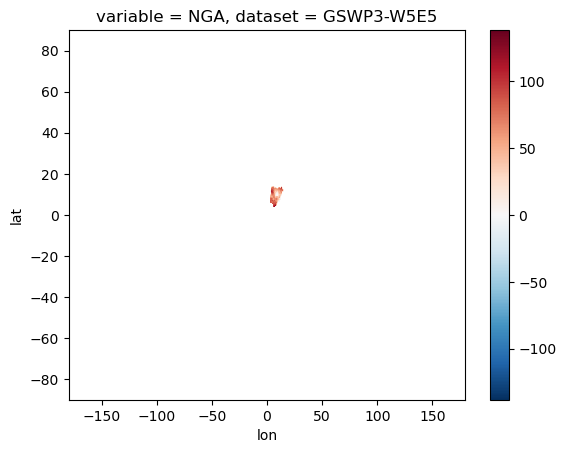

In [18]:
(countrymasks_nan * da_nAHD_obs).sel(variable='NGA').isel(dataset=0).plot()

In [19]:
# per country area-weighted mean nAHD per year

df_nAHD_countries = (countrymasks_nan * da_nAHD_obs).weighted(cellarea).mean(dim=['lat','lon']).to_pandas()
df = df_nAHD_countries
df_nAHD_countries_summary = reporting_summary(df, ['median', 'min', 'max'])
df_nAHD_countries_summary

,median,min,max
variable,,,
AFG,0.299196,0.174910,0.621176
AGO,1.731367,0.927226,4.617867
ALB,2.325441,0.204139,2.451657
AND,0.000853,0.000065,0.000869
ARE,10.934089,7.439406,12.368931
...,...,...,...
WSM,0.098729,0.098729,0.209402
YEM,8.003799,7.766036,14.827932
ZAF,2.200457,0.607540,2.214580


In [20]:
# do also for p1 and p0 to give pi, present and change, 

df_p0_countries = (countrymasks_nan * da_p0_obs).weighted(cellarea).mean(dim=['lat','lon']).to_pandas()
df_p0_summary = df_p0_countries.agg(['median', 'min', 'max'],axis=1)
df_p0_summary

,median,min,max
variable,,,
AFG,0.934444,0.820697,0.941782
AGO,1.619553,0.172900,3.008043
ALB,0.415174,0.029898,0.517047
AND,0.000020,0.000007,0.000057
ARE,80.782456,78.977127,92.847329
...,...,...,...
WSM,0.003290,0.002740,0.003290
YEM,28.371484,20.986820,28.525736
ZAF,1.330037,0.562479,1.509263


In [21]:

df_p1_countries = (countrymasks_nan * da_p1_obs).weighted(cellarea).mean(dim=['lat','lon']).to_pandas()
df_p1_summary = df_p1_countries.agg(['median', 'min', 'max'], axis=1)
df_p1_summary

,median,min,max
variable,,,
AFG,1.233640,0.995607,1.562958
AGO,4.739410,1.100126,6.237420
ALB,2.842488,0.234037,2.866831
AND,0.000889,0.000072,0.000910
ARE,89.911215,88.221862,105.216260
...,...,...,...
WSM,0.102019,0.102019,0.212143
YEM,36.291773,35.814752,36.375283
ZAF,3.544617,1.170019,3.709720


In [22]:
df_nAHD_countries_summary.loc[['DEU', 'CIV']].round(1)

# Germany and Cote d'Ivoire results

,median,min,max
variable,,,
DEU,0.1,0.1,0.2
CIV,53.2,46.9,70.0


In [25]:
df_p0_summary.loc[['DEU', 'CIV']].round(1)

,median,min,max
variable,,,
DEU,0.0,0.0,0.0
CIV,51.2,14.7,64.8


In [24]:
df_p1_summary.loc[['DEU', 'CIV']].round(1)

,median,min,max
variable,,,
DEU,0.1,0.1,0.2
CIV,111.7,67.9,121.2


In [26]:
53.2+51.2

104.4

In [ ]:
df_nAHD_countries.loc[['DEU', 'CIV']].round(1)

# attributable number of days

dataset,GSWP3-W5E5,20CRv3-ERA5,20CRv3-W5E5
variable,,,
DEU,0.2,0.1,0.1
CIV,46.9,53.2,70.0


In [ ]:
df_p0_countries.loc[['DEU', 'CIV']].round(1)

# pre industrial number of days

dataset,GSWP3-W5E5,20CRv3-ERA5,20CRv3-W5E5
variable,,,
DEU,0.0,0.0,0.0
CIV,64.8,14.7,51.2


In [ ]:
df_p1_countries.loc[['DEU', 'CIV']].round(1)

# present-day number of days 

dataset,GSWP3-W5E5,20CRv3-ERA5,20CRv3-W5E5
variable,,,
DEU,0.2,0.1,0.1
CIV,111.7,67.9,121.2


## climate: GCMs

In [30]:
# per country population-weighted mean nAHD per year

df_nAHD_countries = (countrymasks_nan * da_nAHD_models).weighted(popweights).mean(dim=['lat','lon']).to_pandas()
df_nAHD_countries_summary_models = reporting_summary(df_nAHD_countries, ['median', 'min', 'max'])
df_nAHD_countries_summary_models

,median,min,max
variable,,,
AFG,2.117185,1.372070,3.740240
AGO,11.445863,6.113210,17.444573
ALB,2.520261,1.544239,4.751509
AND,0.000000,0.000000,0.000167
ARE,30.960269,30.266377,38.511351
...,...,...,...
WSM,0.016720,0.000000,0.188212
YEM,12.263967,10.013915,14.487128
ZAF,2.504371,1.694479,4.579884


In [31]:
# do also for p1 and p0 to give pi, present and change, 

# df_p0_countries = (countrymasks_nan * da_p0_models).weighted(cellarea).mean(dim=['lat','lon']).to_pandas()
# df_p0_summary_models = df_p0_countries.agg(['median', 'min', 'max'],axis=1)
# df_p0_summary_models

In [32]:

# df_p1_countries = (countrymasks_nan * da_p1_models).weighted(cellarea).mean(dim=['lat','lon']).to_pandas()
# df_p1_summary_models = df_p1_countries.agg(['median', 'min', 'max'], axis=1)
# df_p1_summary_models

In [33]:
df_nAHD_countries = (countrymasks_nan * da_nAHD_models_15).weighted(popweights_15).mean(dim=['lat','lon']).to_pandas()
df_nAHD_countries_summary_models_15 = reporting_summary(df_nAHD_countries, ['median', 'min', 'max'])

df_nAHD_countries = (countrymasks_nan * da_nAHD_models_2).weighted(popweights_2).mean(dim=['lat','lon']).to_pandas()
df_nAHD_countries_summary_models_2 = reporting_summary(df_nAHD_countries, ['median', 'min', 'max'])

# nAHD at 1.5 and 2 deg

In [34]:
df_p1_countries = (countrymasks_nan * da_p1_models_15).weighted(popweights_15).mean(dim=['lat','lon']).to_pandas()
df_p1_summary_models_15 = df_p1_countries.agg(['median', 'min', 'max'], axis=1)

df_p1_countries = (countrymasks_nan * da_p1_models_2).weighted(popweights_2).mean(dim=['lat','lon']).to_pandas()
df_p1_summary_models_2 = df_p1_countries.agg(['median', 'min', 'max'], axis=1)

# total days at 1.5 and 2 deg

## 2.1 number and % of kids exposed to one extra month (GCMs)


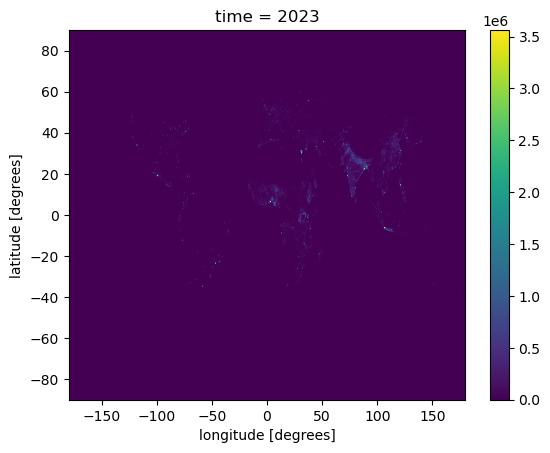

In [35]:
gs_population_global.sel(ages=slice(0,9)).sum(dim='ages').plot()

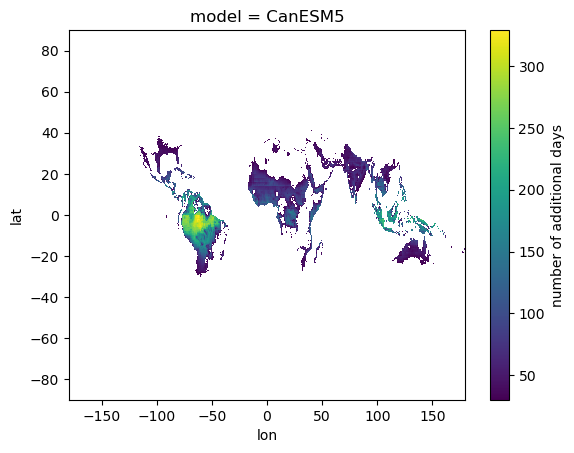

In [36]:
da_nAHD_models.where(da_nAHD_models>30).isel(model=0).plot()

In [37]:
# present-day

children_1month = (
    gs_population_global
    .sel(ages=slice(0, 9))
    .sum(dim="ages")
    .where(da_nAHD_models > 30)
)

children_tot_per_country = (
    gs_population_global
    .sel(ages=slice(0, 9))
    .sum(dim="ages")
    * countrymasks_nan
).sum(dim=("lat", "lon"), skipna=True)


children_per_country = (
    children_1month * countrymasks_nan
).sum(dim=("lat", "lon"), skipna=True)

df_children_per_country = (
    children_per_country.median(dim='model')
    .to_dataframe(name="children_exposed_1month_present")
    .reset_index()
    .rename(columns={"variable": "country"})
    .drop(columns='time')
    .set_index('country')
)

df_children_percent_per_country = (
    ((children_per_country.median(dim='model') / children_tot_per_country) * 100)
    .to_dataframe(name="children_percent_1month_present")
    .reset_index()
    .rename(columns={"variable": "country"})
    .drop(columns='time')
    .set_index('country')
)

df_children_per_country

# make this a fxn !

,children_exposed_1month_present
country,
AFG,1.697629e+05
AGO,2.423615e+06
ALB,0.000000e+00
AND,0.000000e+00
ARE,5.358796e+05
...,...
WSM,0.000000e+00
YEM,1.960968e+06
ZAF,6.398542e+04


In [38]:
# 1.5

children_1month = (
    gs_population_global_15
    .sel(ages=slice(0, 9))
    .sum(dim="ages")
    .where(da_nAHD_models_15 > 30)
)

children_per_country = (
    children_1month * countrymasks_nan
).sum(dim=("lat", "lon"), skipna=True)

children_tot_per_country = (
    gs_population_global_15
    .sel(ages=slice(0, 9))
    .sum(dim="ages")
    * countrymasks_nan
).sum(dim=("lat", "lon"), skipna=True)



df_children_per_country_15 = (
    children_per_country.median(dim='model')
    .to_dataframe(name="children_exposed_1month_15deg")
    .reset_index()
    .rename(columns={"variable": "country"})
    .drop(columns='time')
    .set_index('country')
)

df_children_percent_per_country_15 = (
    ((children_per_country.median(dim='model') / children_tot_per_country) * 100)
    .to_dataframe(name="children_percent_1month_present")
    .reset_index()
    .rename(columns={"variable": "country"})
    .drop(columns='time')
    .set_index('country')
)

df_children_per_country_15

,children_exposed_1month_15deg
country,
AFG,3.066786e+05
AGO,2.791486e+06
ALB,0.000000e+00
AND,0.000000e+00
ARE,6.888116e+05
...,...
WSM,0.000000e+00
YEM,2.279939e+06
ZAF,2.331585e+05


In [39]:
# 2 deg

children_1month = (
    gs_population_global_2
    .sel(ages=slice(0, 9))
    .sum(dim="ages")
    .where(da_nAHD_models_2 > 30)
)

children_per_country = (
    children_1month * countrymasks_nan
).sum(dim=("lat", "lon"), skipna=True)

children_tot_per_country = (
    gs_population_global_2
    .sel(ages=slice(0, 9))
    .sum(dim="ages")
    * countrymasks_nan
).sum(dim=("lat", "lon"), skipna=True)



df_children_per_country_2 = (
    children_per_country.median(dim='model')
    .to_dataframe(name="children_exposed_1month_2deg")
    .reset_index()
    .rename(columns={"variable": "country"})
    .drop(columns='time')
    .set_index('country')
)

df_children_percent_per_country_2 = (
    ((children_per_country.median(dim='model') / children_tot_per_country) * 100)
    .to_dataframe(name="children_percent_1month_2")
    .reset_index()
    .rename(columns={"variable": "country"})
    .drop(columns='time')
    .set_index('country')
)

df_children_per_country_2

,children_exposed_1month_2deg
country,
AFG,1.310249e+06
AGO,3.390730e+06
ALB,4.208198e+03
AND,0.000000e+00
ARE,7.621872e+05
...,...
WSM,0.000000e+00
YEM,2.373499e+06
ZAF,7.308663e+05


In [40]:
df_chidren_per_country_merged = pd.concat([df_children_per_country, df_children_per_country_15, df_children_per_country_2], axis=1)

df_chidren_per_country_merged = (df_chidren_per_country_merged / 1e3).round() # in thousands of children

### summary: clean & combine

In [41]:
# reanalysis

# df1 = df_nAHD_countries_summary.rename(
#     columns=({'median':'nAHD_r_BE','min':'nAHD_r_min','max':'nAHD_r_max'})
#     ).round(1)

In [42]:
# df2 = df_p1_summary.rename(
#     columns=({'median':'totdays_r_BE','min':'totdays_r_min','max':'totdays_r_max'})
#     ).round(1)

#### GCMs

In [43]:
df3 = df_nAHD_countries_summary_models.rename(
    columns=({'median':'nAHD_m_BE','min':'nAHD_m_min','max':'nAHD_m_max'})
    ).round(1)

In [44]:
df3a = df_nAHD_countries_summary_models_15.rename(
    columns=({'median':'nAHD_m_15deg_BE','min':'nAHD_m_15deg_min','max':'nAHD_m_15deg_max'})
    ).round(1)

In [45]:
df3b = df_nAHD_countries_summary_models_2.rename(
    columns=({'median':'nAHD_m_2deg_BE','min':'nAHD_m_2deg_min','max':'nAHD_m_2deg_max'})
    ).round(1)

In [46]:
# df4 = df_p1_summary_models.rename(
#     columns=({'median':'totdays_m_BE','min':'totdays_m_min','max':'totdays_m_max'})
#     ).round(1)

In [47]:
# df5 = df_p1_summary_models_15.rename(
#     columns=({'median':'totdays_m_15deg_BE','min':'totdays_m_15deg_min','max':'totdays_m_15deg_max'})
#     ).round(1)

In [48]:
# df6 = df_p1_summary_models_2.rename(
#     columns=({'median':'totdays_m_2deg_BE','min':'totdays_m_2deg_min','max':'totdays_m_2deg_max'})
#     ).round(1)

In [49]:
# df_allresults_countries = pd.concat([df1, df2, df3, df3a, df3b, df4, df5, df6], axis=1)
# df_allresults_countries

In [50]:

# df = df_allresults_countries
# df_allresults_countries_BE = df.loc[:, ~df.columns.str.contains('min|max')]
# df_allresults_countries_BE

#### new 

In [51]:
df3

,nAHD_m_BE,nAHD_m_min,nAHD_m_max
variable,,,
AFG,2.1,1.4,3.7
AGO,11.4,6.1,17.4
ALB,2.5,1.5,4.8
AND,0.0,0.0,0.0
ARE,31.0,30.3,38.5
...,...,...,...
WSM,0.0,0.0,0.2
YEM,12.3,10.0,14.5
ZAF,2.5,1.7,4.6


In [52]:
df_clean_merged = pd.concat([
    df_chidren_per_country_merged.rename(columns={
        'children_exposed_1month_present': 'Number of children exposed to one additional month of heat stress due to climate change in present day (thousands)',
        'children_exposed_1month_15deg': 'Number of children exposed to one additional month of heat stress due to climate change under 1.5°C of warming (thousands)',
        'children_exposed_1month_2deg': 'Number of children exposed to one additional month of heat stress due to climate change under 2°C of warming (thousands)'
    }), 
    df3['nAHD_m_BE'].rename('Additional heat stress days per year due to climate change in present day (country average, population-weighted)'), 
    df3a['nAHD_m_15deg_BE'].rename('Additional heat stress days per year due to climate change under 1.5°C warming (country average, population-weighted)'), 
    df3b['nAHD_m_2deg_BE'].rename('Additional heat stress days per year due to climate change under 2°C warming (country average, population-weighted)')
], axis=1)

df_clean_merged

,Number of children exposed to one additional month of heat stress due to climate change in present day (thousands),Number of children exposed to one additional month of heat stress due to climate change under 1.5°C of warming (thousands),Number of children exposed to one additional month of heat stress due to climate change under 2°C of warming (thousands),"Additional heat stress days per year due to climate change in present day (country average, population-weighted)","Additional heat stress days per year due to climate change under 1.5°C warming (country average, population-weighted)","Additional heat stress days per year due to climate change under 2°C warming (country average, population-weighted)"
AFG,170.0,307.0,1310.0,2.1,2.9,5.1
AGO,2424.0,2791.0,3391.0,11.4,14.1,24.3
ALB,0.0,0.0,4.0,2.5,3.2,5.8
AND,0.0,0.0,0.0,0.0,0.0,0.0
ARE,536.0,689.0,762.0,31.0,35.0,46.7
...,...,...,...,...,...,...
WSM,0.0,0.0,0.0,0.0,0.2,2.2
YEM,1961.0,2280.0,2373.0,12.3,14.6,20.0
ZAF,64.0,233.0,731.0,2.5,3.4,6.3
ZMB,51.0,155.0,883.0,1.8,2.6,7.2


In [53]:
df_countries_matched = match_country_names_all_mask_frac();
df_countrynames = df_countries_matched[[ 'iso3_frac', 'country_wcde']].dropna().set_index('iso3_frac').rename(columns={'country_wcde':'Country'})
df_countrynames

Unmatched ISIMIP countries (without WCDE data) after all merges:
                   country           country_wb
194                Andorra              Andorra
196               Dominica             Dominica
199                  Palau                Palau
7            Liechtenstein        Liechtenstein
8         Marshall Islands     Marshall Islands
9                   Monaco               Monaco
10                   Nauru                Nauru
12   Saint Kitts and Nevis  St. Kitts and Nevis
13              San Marino           San Marino
14                  Tuvalu               Tuvalu
Unmatched WCDE countries after all merges:
                                   country_wcde
2                                         Aruba
3                               Channel Islands
4                                       Curaçao
5  Macao Special Administrative Region of China
6                                         World
Unmatched ISIMIP mask countries (geojson + frac mask) after all merges:
    

,Country
iso3_frac,
AFG,Afghanistan
ALB,Albania
DZA,Algeria
AGO,Angola
ATG,Antigua and Barbuda
...,...
PRI,Puerto Rico
REU,Reunion
TWN,Taiwan Province of China


In [54]:
df_clean_merged_countrynames = df_countrynames.merge(df_clean_merged, left_index=True, right_index=True)
df_clean_merged_countrynames = df_clean_merged_countrynames.sort_values(by='Country').set_index('Country',drop=True)
df_clean_merged_countrynames

,Number of children exposed to one additional month of heat stress due to climate change in present day (thousands),Number of children exposed to one additional month of heat stress due to climate change under 1.5°C of warming (thousands),Number of children exposed to one additional month of heat stress due to climate change under 2°C of warming (thousands),"Additional heat stress days per year due to climate change in present day (country average, population-weighted)","Additional heat stress days per year due to climate change under 1.5°C warming (country average, population-weighted)","Additional heat stress days per year due to climate change under 2°C warming (country average, population-weighted)"
Country,,,,,,
Afghanistan,170.0,307.0,1310.0,2.1,2.9,5.1
Albania,0.0,0.0,4.0,2.5,3.2,5.8
Algeria,367.0,637.0,1146.0,8.2,10.6,16.5
Angola,2424.0,2791.0,3391.0,11.4,14.1,24.3
Antigua and Barbuda,0.0,0.0,0.0,0.0,0.1,1.5
...,...,...,...,...,...,...
Viet Nam,13169.0,10876.0,8019.0,65.0,74.1,94.1
Western Sahara,10.0,20.0,59.0,13.4,16.7,24.4
Yemen,1961.0,2280.0,2373.0,12.3,14.6,20.0


In [55]:
#df_clean_merged_countrynames.to_excel(figdir+'/supplementary_data_GCMs_1mo_v2.xlsx')


In [56]:
figdir

'/data/brussel/vo/000/bvo00012/vsc10419/attr-hw/figures/fig_apr26'

#### add % children

In [57]:
df_children_fmt = df_chidren_per_country_merged.copy()

df_children_fmt['children_exposed_1month_present'] = (
    df_children_fmt['children_exposed_1month_present'].round(0).astype(int).astype(str)
    + " ("
    + df_children_percent_per_country['children_percent_1month_present'].round(0).astype("Int64").astype(str)
    + "%)"
)

df_children_fmt['children_exposed_1month_15deg'] = (
    df_children_fmt['children_exposed_1month_15deg'].round(0).astype(int).astype(str)
    + " ("
    + df_children_percent_per_country_15['children_percent_1month_present'].round(0).astype("Int64").astype(str)
    + "%)"
)

df_children_fmt['children_exposed_1month_2deg'] = (
    df_children_fmt['children_exposed_1month_2deg'].round(0).astype(int).astype(str)
    + " ("
    + df_children_percent_per_country_2['children_percent_1month_2'].round(0).astype("Int64").astype(str)
    + "%)"
)

df_children_fmt.head(20)

,children_exposed_1month_present,children_exposed_1month_15deg,children_exposed_1month_2deg
country,,,
AFG,170 (1%),307 (2%),1310 (7%)
AGO,2424 (22%),2791 (24%),3391 (30%)
ALB,0 (0%),0 (0%),4 (3%)
AND,0 (0%),0 (0%),0 (0%)
ARE,536 (64%),689 (92%),762 (100%)
ARG,443 (6%),684 (10%),731 (12%)
ARM,0 (0%),0 (0%),0 (0%)
ASM,0 (<NA>%),0 (<NA>%),0 (<NA>%)
ATF,0 (<NA>%),0 (<NA>%),0 (<NA>%)


In [58]:
df_clean_merged = pd.concat([
    df_children_fmt.rename(columns={
        'children_exposed_1month_present': 'Number of children exposed to one additional month of heat stress due to climate change in present day (thousands, %)',
        'children_exposed_1month_15deg': 'Number of children exposed to one additional month of heat stress due to climate change under 1.5°C of warming (thousands, %)',
        'children_exposed_1month_2deg': 'Number of children exposed to one additional month of heat stress due to climate change under 2°C of warming (thousands, %)'
    }), 
    df3['nAHD_m_BE'].rename('Additional heat stress days per year due to climate change in present day (country average, population-weighted)'), 
    df3a['nAHD_m_15deg_BE'].rename('Additional heat stress days per year due to climate change under 1.5°C warming (country average, population-weighted)'), 
    df3b['nAHD_m_2deg_BE'].rename('Additional heat stress days per year due to climate change under 2°C warming (country average, population-weighted)')
], axis=1)

df_clean_merged_countrynames = df_countrynames.merge(df_clean_merged, left_index=True, right_index=True)
df_clean_merged_countrynames = df_clean_merged_countrynames.sort_values(by='Country').set_index('Country',drop=True)

df_clean_merged_countrynames

,"Number of children exposed to one additional month of heat stress due to climate change in present day (thousands, %)","Number of children exposed to one additional month of heat stress due to climate change under 1.5°C of warming (thousands, %)","Number of children exposed to one additional month of heat stress due to climate change under 2°C of warming (thousands, %)","Additional heat stress days per year due to climate change in present day (country average, population-weighted)","Additional heat stress days per year due to climate change under 1.5°C warming (country average, population-weighted)","Additional heat stress days per year due to climate change under 2°C warming (country average, population-weighted)"
Country,,,,,,
Afghanistan,170 (1%),307 (2%),1310 (7%),2.1,2.9,5.1
Albania,0 (0%),0 (0%),4 (3%),2.5,3.2,5.8
Algeria,367 (4%),637 (9%),1146 (20%),8.2,10.6,16.5
Angola,2424 (22%),2791 (24%),3391 (30%),11.4,14.1,24.3
Antigua and Barbuda,0 (0%),0 (0%),0 (0%),0.0,0.1,1.5
...,...,...,...,...,...,...
Viet Nam,13169 (92%),10876 (95%),8019 (97%),65.0,74.1,94.1
Western Sahara,10 (9%),20 (18%),59 (48%),13.4,16.7,24.4
Yemen,1961 (23%),2280 (24%),2373 (25%),12.3,14.6,20.0


In [59]:
df_clean_merged_countrynames_1mo = df_clean_merged_countrynames.copy()

In [60]:
#df_clean_merged_countrynames.to_excel(figdir+'/supplementary_data_GCMs_1mo_v2.xlsx')


## 2.2 number and % of kids exposed to at least 5 total months

In [61]:
condition = (da_p1_models>150)


children_exp = (
    gs_population_global
    .sel(ages=slice(0, 9))
    .sum(dim="ages")
    .where(condition)
)

children_tot_per_country = (
    gs_population_global
    .sel(ages=slice(0, 9))
    .sum(dim="ages")
    * countrymasks_nan
).sum(dim=("lat", "lon"), skipna=True)


children_per_country = (
    children_exp * countrymasks_nan
).sum(dim=("lat", "lon"), skipna=True)

df_children_per_country_5mo = (
    children_per_country.median(dim='model')
    .to_dataframe(name="children_exposed_5month_present")
    .reset_index()
    .rename(columns={"variable": "country"})
    .drop(columns='time')
    .set_index('country')
)

df_children_percent_per_country_5mo = (
    ((children_per_country.median(dim='model') / children_tot_per_country) * 100)
    .to_dataframe(name="children_percent_5month_present")
    .reset_index()
    .rename(columns={"variable": "country"})
    .drop(columns='time')
    .set_index('country')
)

df_children_per_country_5mo

,children_exposed_5month_present
country,
AFG,0.000000e+00
AGO,0.000000e+00
ALB,0.000000e+00
AND,0.000000e+00
ARE,5.258532e+05
...,...
WSM,0.000000e+00
YEM,1.118748e+06
ZAF,0.000000e+00


In [62]:
condition = (da_p0_models>150)


children_exp = (
    gs_population_global
    .sel(ages=slice(0, 9))
    .sum(dim="ages")
    .where(condition)
)

children_tot_per_country = (
    gs_population_global
    .sel(ages=slice(0, 9))
    .sum(dim="ages")
    * countrymasks_nan
).sum(dim=("lat", "lon"), skipna=True)


children_per_country = (
    children_exp * countrymasks_nan
).sum(dim=("lat", "lon"), skipna=True)

df_children_per_country_5mo_pi = (
    children_per_country.median(dim='model')
    .to_dataframe(name="children_exposed_5month_pi")
    .reset_index()
    .rename(columns={"variable": "country"})
    .drop(columns='time')
    .set_index('country')
)

df_children_percent_per_country_5mo_pi = (
    ((children_per_country.median(dim='model') / children_tot_per_country) * 100)
    .to_dataframe(name="children_percent_5month_pi")
    .reset_index()
    .rename(columns={"variable": "country"})
    .drop(columns='time')
    .set_index('country')
)

df_children_per_country_5mo_pi

,children_exposed_5month_pi
country,
AFG,0.000000
AGO,0.000000
ALB,0.000000
AND,0.000000
ARE,112946.323799
...,...
WSM,0.000000
YEM,734982.542104
ZAF,0.000000


In [63]:
condition = (da_p1_models_15>150)


children_exp = (
    gs_population_global_15
    .sel(ages=slice(0, 9))
    .sum(dim="ages")
    .where(condition)
)

children_per_country = (
    children_exp * countrymasks_nan
).sum(dim=("lat", "lon"), skipna=True)

children_tot_per_country = (
    gs_population_global_15
    .sel(ages=slice(0, 9))
    .sum(dim="ages")
    * countrymasks_nan
).sum(dim=("lat", "lon"), skipna=True)


df_children_per_country_15_5mo = (
    children_per_country.median(dim='model')
    .to_dataframe(name="children_exposed_5month_15deg")
    .reset_index()
    .rename(columns={"variable": "country"})
    .drop(columns='time')
    .set_index('country')
)

df_children_percent_per_country_15_5mo = (
    ((children_per_country.median(dim='model') / children_tot_per_country) * 100)
    .to_dataframe(name="children_percent_5month_present")
    .reset_index()
    .rename(columns={"variable": "country"})
    .drop(columns='time')
    .set_index('country')
)

df_children_percent_per_country_15_5mo

,children_percent_5month_present
country,
AFG,0.000000
AGO,0.108689
ALB,0.000000
AND,0.000000
ARE,65.099968
...,...
WSM,0.000000
YEM,13.846968
ZAF,0.000000


In [64]:
condition = (da_p1_models_2>150)


children_exp = (
    gs_population_global_2
    .sel(ages=slice(0, 9))
    .sum(dim="ages")
    .where(condition)
)

children_per_country = (
    children_exp * countrymasks_nan
).sum(dim=("lat", "lon"), skipna=True)

children_tot_per_country = (
    gs_population_global_2
    .sel(ages=slice(0, 9))
    .sum(dim="ages")
    * countrymasks_nan
).sum(dim=("lat", "lon"), skipna=True)


df_children_per_country_2_5mo = (
    children_per_country.median(dim='model')
    .to_dataframe(name="children_exposed_5month_2deg")
    .reset_index()
    .rename(columns={"variable": "country"})
    .drop(columns='time')
    .set_index('country')
)

df_children_percent_per_country_2_5mo = (
    ((children_per_country.median(dim='model') / children_tot_per_country) * 100)
    .to_dataframe(name="children_percent_5month_2")
    .reset_index()
    .rename(columns={"variable": "country"})
    .drop(columns='time')
    .set_index('country')
)

df_children_percent_per_country_2_5mo

,children_percent_5month_2
country,
AFG,0.000000
AGO,1.977407
ALB,0.000000
AND,0.000000
ARE,72.299931
...,...
WSM,0.000000
YEM,17.046980
ZAF,0.000000


In [65]:
df_chidren_per_country_merged_5mo = pd.concat([df_children_per_country_5mo, df_children_per_country_15_5mo, df_children_per_country_2_5mo], axis=1)

df_chidren_per_country_merged_5mo = (df_chidren_per_country_merged_5mo / 1e3).round() # in thousands of children

df_chidren_per_country_merged_5mo

,children_exposed_5month_present,children_exposed_5month_15deg,children_exposed_5month_2deg
country,,,
AFG,0.0,0.0,0.0
AGO,0.0,13.0,224.0
ALB,0.0,0.0,0.0
AND,0.0,0.0,0.0
ARE,526.0,490.0,551.0
...,...,...,...
WSM,0.0,0.0,0.0
YEM,1119.0,1325.0,1639.0
ZAF,0.0,0.0,0.0


In [66]:
df_countries_matched = match_country_names_all_mask_frac();
df_countrynames = df_countries_matched[[ 'iso3_frac', 'country_wcde']].dropna().set_index('iso3_frac').rename(columns={'country_wcde':'Country'})
df_countrynames

Unmatched ISIMIP countries (without WCDE data) after all merges:
                   country           country_wb
194                Andorra              Andorra
196               Dominica             Dominica
199                  Palau                Palau
7            Liechtenstein        Liechtenstein
8         Marshall Islands     Marshall Islands
9                   Monaco               Monaco
10                   Nauru                Nauru
12   Saint Kitts and Nevis  St. Kitts and Nevis
13              San Marino           San Marino
14                  Tuvalu               Tuvalu
Unmatched WCDE countries after all merges:
                                   country_wcde
2                                         Aruba
3                               Channel Islands
4                                       Curaçao
5  Macao Special Administrative Region of China
6                                         World
Unmatched ISIMIP mask countries (geojson + frac mask) after all merges:
    

,Country
iso3_frac,
AFG,Afghanistan
ALB,Albania
DZA,Algeria
AGO,Angola
ATG,Antigua and Barbuda
...,...
PRI,Puerto Rico
REU,Reunion
TWN,Taiwan Province of China


In [67]:
pd.concat([df_children_percent_per_country_5mo,df_children_percent_per_country_15_5mo,df_children_percent_per_country_2_5mo],axis=1).round(1).head(40)

,children_percent_5month_present,children_percent_5month_present,children_percent_5month_2
country,,,
AFG,0.0,0.0,0.0
AGO,0.0,0.1,2.0
ALB,0.0,0.0,0.0
AND,0.0,0.0,0.0
ARE,62.5,65.1,72.3
ARG,0.0,0.0,0.0
ARM,0.0,0.0,0.0
ASM,NaN,NaN,NaN
ATF,NaN,NaN,NaN


#### pi numbers

In [68]:
# save pi table

df_merged_5mo_pi = pd.concat([ df_children_per_country_5mo_pi / 1e3,df_children_percent_per_country_5mo_pi],axis=1)
df_merged_5mo_pi

,children_exposed_5month_pi,children_percent_5month_pi
country,,
AFG,0.000000,0.000000
AGO,0.000000,0.000000
ALB,0.000000,0.000000
AND,0.000000,0.000000
ARE,112.946324,13.427184
...,...,...
WSM,0.000000,0.000000
YEM,734.982542,8.620951
ZAF,0.000000,0.000000


In [69]:


df_clean_merged_countrynames_5mo_pi = df_countrynames.merge(df_merged_5mo_pi.round(), left_index=True, right_index=True)
df_clean_merged_countrynames_5mo_pi

,Country,children_exposed_5month_pi,children_percent_5month_pi
AFG,Afghanistan,0.0,0.0
ALB,Albania,0.0,0.0
DZA,Algeria,0.0,0.0
AGO,Angola,0.0,0.0
ATG,Antigua and Barbuda,0.0,0.0
...,...,...,...
PRI,Puerto Rico,0.0,0.0
REU,Reunion,0.0,0.0
TWN,Taiwan Province of China,0.0,0.0
VIR,United States Virgin Islands,0.0,0.0


In [70]:
#df_clean_merged_countrynames_5mo_pi.to_excel(figdir+'/supplementary_data_GCMs_5mo_pi.xlsx')


### clean and format

In [71]:
df_children_fmt = df_chidren_per_country_merged_5mo.copy()

df_children_fmt.insert(0, 'children_exposed_5month_pi', df_clean_merged_countrynames_5mo_pi['children_exposed_5month_pi'])

df_children_fmt['children_exposed_5month_pi'] = (
    df_clean_merged_countrynames_5mo_pi['children_exposed_5month_pi'].round(0).astype(int).astype(str)
    + " ("
    + df_clean_merged_countrynames_5mo_pi['children_percent_5month_pi'].round(0).astype("Int64").astype(str)
    + "%)"
)

df_children_fmt['children_exposed_5month_present'] = (
    df_children_fmt['children_exposed_5month_present'].round(0).astype(int).astype(str)
    + " ("
    + df_children_percent_per_country_5mo['children_percent_5month_present'].round(0).astype("Int64").astype(str)
    + "%)"
)

df_children_fmt['children_exposed_5month_15deg'] = (
    df_children_fmt['children_exposed_5month_15deg'].round(0).astype(int).astype(str)
    + " ("
    + df_children_percent_per_country_15_5mo['children_percent_5month_present'].round(0).astype("Int64").astype(str)
    + "%)"
)

df_children_fmt['children_exposed_5month_2deg'] = (
    df_children_fmt['children_exposed_5month_2deg'].round(0).astype(int).astype(str)
    + " ("
    + df_children_percent_per_country_2_5mo['children_percent_5month_2'].round(0).astype("Int64").astype(str)
    + "%)"
)

df_children_fmt.head(40)

,children_exposed_5month_pi,children_exposed_5month_present,children_exposed_5month_15deg,children_exposed_5month_2deg
country,,,,
AFG,0 (0%),0 (0%),0 (0%),0 (0%)
AGO,0 (0%),0 (0%),13 (0%),224 (2%)
ALB,0 (0%),0 (0%),0 (0%),0 (0%)
AND,NaN,0 (0%),0 (0%),0 (0%)
ARE,113 (13%),526 (63%),490 (65%),551 (72%)
ARG,0 (0%),0 (0%),0 (0%),0 (0%)
ARM,0 (0%),0 (0%),0 (0%),0 (0%)
ASM,NaN,0 (<NA>%),0 (<NA>%),0 (<NA>%)
ATF,NaN,0 (<NA>%),0 (<NA>%),0 (<NA>%)


In [72]:
df_clean_merged_5mo = pd.concat([
    df_children_fmt.rename(columns={
        'children_exposed_5month_pi': 'Number of children exposed to five total months of heat stress in a hypothetical pre-industrial climate (thousands, %)',
        'children_exposed_5month_present': 'Number of children exposed to five total months of heat stress in present day (thousands, %)',
        'children_exposed_5month_15deg': 'Number of children exposed to five total months of heat stress under 1.5°C of warming (thousands, %)',
        'children_exposed_5month_2deg': 'Number of children exposed to five total months of heat stress under 2°C of warming (thousands, %)'
    }), 
], axis=1)

df_clean_merged_countrynames_5mo = df_countrynames.merge(df_clean_merged_5mo, left_index=True, right_index=True).sort_values('Country').set_index('Country',drop=True)
df_clean_merged_countrynames_5mo

,"Number of children exposed to five total months of heat stress in a hypothetical pre-industrial climate (thousands, %)","Number of children exposed to five total months of heat stress in present day (thousands, %)","Number of children exposed to five total months of heat stress under 1.5°C of warming (thousands, %)","Number of children exposed to five total months of heat stress under 2°C of warming (thousands, %)"
Country,,,,
Afghanistan,0 (0%),0 (0%),0 (0%),0 (0%)
Albania,0 (0%),0 (0%),0 (0%),0 (0%)
Algeria,0 (0%),0 (0%),0 (0%),0 (0%)
Angola,0 (0%),0 (0%),13 (0%),224 (2%)
Antigua and Barbuda,0 (0%),0 (0%),0 (0%),0 (0%)
...,...,...,...,...
Viet Nam,3101 (22%),8426 (59%),7933 (69%),6898 (84%)
Western Sahara,0 (0%),0 (0%),0 (0%),0 (0%)
Yemen,735 (9%),1119 (13%),1325 (14%),1639 (17%)


In [73]:
#df_clean_merged_countrynames_5mo.to_excel(figdir+'/supplementary_data_GCMs_5mo_v2.xlsx')


In [74]:
figdir

'/data/brussel/vo/000/bvo00012/vsc10419/attr-hw/figures/fig_apr26'

## 2.3 version with both 1 month and 5 months in same table

In [75]:
df_clean_merged_countrynames_5mo

,"Number of children exposed to five total months of heat stress in a hypothetical pre-industrial climate (thousands, %)","Number of children exposed to five total months of heat stress in present day (thousands, %)","Number of children exposed to five total months of heat stress under 1.5°C of warming (thousands, %)","Number of children exposed to five total months of heat stress under 2°C of warming (thousands, %)"
Country,,,,
Afghanistan,0 (0%),0 (0%),0 (0%),0 (0%)
Albania,0 (0%),0 (0%),0 (0%),0 (0%)
Algeria,0 (0%),0 (0%),0 (0%),0 (0%)
Angola,0 (0%),0 (0%),13 (0%),224 (2%)
Antigua and Barbuda,0 (0%),0 (0%),0 (0%),0 (0%)
...,...,...,...,...
Viet Nam,3101 (22%),8426 (59%),7933 (69%),6898 (84%)
Western Sahara,0 (0%),0 (0%),0 (0%),0 (0%)
Yemen,735 (9%),1119 (13%),1325 (14%),1639 (17%)


In [76]:
df_clean_merged_countrynames_5mo_1mo = pd.concat(
    [
        
        df_clean_merged_countrynames_1mo.iloc[:, :3],
        df_clean_merged_countrynames_5mo,
        df_clean_merged_countrynames_1mo.iloc[:, 3:],
    ],
    axis=1,
)
df_clean_merged_countrynames_5mo_1mo

,"Number of children exposed to one additional month of heat stress due to climate change in present day (thousands, %)","Number of children exposed to one additional month of heat stress due to climate change under 1.5°C of warming (thousands, %)","Number of children exposed to one additional month of heat stress due to climate change under 2°C of warming (thousands, %)","Number of children exposed to five total months of heat stress in a hypothetical pre-industrial climate (thousands, %)","Number of children exposed to five total months of heat stress in present day (thousands, %)","Number of children exposed to five total months of heat stress under 1.5°C of warming (thousands, %)","Number of children exposed to five total months of heat stress under 2°C of warming (thousands, %)","Additional heat stress days per year due to climate change in present day (country average, population-weighted)","Additional heat stress days per year due to climate change under 1.5°C warming (country average, population-weighted)","Additional heat stress days per year due to climate change under 2°C warming (country average, population-weighted)"
Country,,,,,,,,,,
Afghanistan,170 (1%),307 (2%),1310 (7%),0 (0%),0 (0%),0 (0%),0 (0%),2.1,2.9,5.1
Albania,0 (0%),0 (0%),4 (3%),0 (0%),0 (0%),0 (0%),0 (0%),2.5,3.2,5.8
Algeria,367 (4%),637 (9%),1146 (20%),0 (0%),0 (0%),0 (0%),0 (0%),8.2,10.6,16.5
Angola,2424 (22%),2791 (24%),3391 (30%),0 (0%),0 (0%),13 (0%),224 (2%),11.4,14.1,24.3
Antigua and Barbuda,0 (0%),0 (0%),0 (0%),0 (0%),0 (0%),0 (0%),0 (0%),0.0,0.1,1.5
...,...,...,...,...,...,...,...,...,...,...
Viet Nam,13169 (92%),10876 (95%),8019 (97%),3101 (22%),8426 (59%),7933 (69%),6898 (84%),65.0,74.1,94.1
Western Sahara,10 (9%),20 (18%),59 (48%),0 (0%),0 (0%),0 (0%),0 (0%),13.4,16.7,24.4
Yemen,1961 (23%),2280 (24%),2373 (25%),735 (9%),1119 (13%),1325 (14%),1639 (17%),12.3,14.6,20.0


In [77]:
#df_clean_merged_countrynames_5mo_1mo.to_excel(figdir+'/supplementary_data_GCMs_5mo_1mo_v1.xlsx')


# 3. AR6 level results (comms) WBGT28

In [78]:
ar6 = regionmask.defined_regions.ar6.land
mask = ar6.mask(da_nAHD_models )


In [79]:
def calc_tot_attr_days_per_region(da_nAHD, da_p1, gs_population, mask):
    
    people_x_nAHD = (da_nAHD * gs_population).squeeze()

    people_x_totaldays= (da_p1 * gs_population).squeeze()


    pop_x_daystot_ar6_sum = (
        people_x_totaldays.sum(dim='ages')
        .groupby(mask)
        .sum(dim=["stacked_lat_lon"])
    )

    pop_x_nAHD_ar6_sum = (
            people_x_nAHD.sum(dim='ages')
        .groupby(mask)
        .sum(dim=["stacked_lat_lon"])


    )

    pop_ar6_sum = (
        gs_population.sum(dim='ages')
        .groupby(mask)
        .sum(dim=["stacked_lat_lon"])
    )

    totdays_per_person = (pop_x_daystot_ar6_sum / pop_ar6_sum).rename({"mask": "region"}).assign_coords(
        region=("region", ar6.names)
    )

    nAHD_per_person = (pop_x_nAHD_ar6_sum / pop_ar6_sum).rename({"mask": "region"}).assign_coords(
        region=("region", ar6.names)
    )

    return nAHD_per_person, totdays_per_person

In [80]:
def calc_number_children_exposed_per_region(
    da,
    gs_population,
    threshold_ndays,
    mask,
    period
    ):

    
    children_exp = (
        gs_population
        .sel(ages=slice(0, 9))
        .sum(dim="ages")
        .where(da > threshold_ndays)
    )

    children_tot_per_country = (
        gs_population
        .sel(ages=slice(0, 9))
        .sum(dim="ages")
        .groupby(mask)
        .sum(dim=["stacked_lat_lon"])
    )

    children_per_country = (
        children_exp
        .groupby(mask)
        .sum(dim=["stacked_lat_lon"])
    )


    
    df_children_per_country = (
        children_per_country.median(dim='model')
        .rename({"mask": "region"})
        .assign_coords(region=("region", ar6.names))
        .squeeze()
        .to_dataframe(name=f"children_exposed_{threshold_ndays}days_{period}")
        .drop(columns='time')
        )

    df_children_percent_per_country = (
        ((children_per_country.median(dim='model') / children_tot_per_country) * 100)
        .rename({"mask": "region"})
        .assign_coords(region=("region", ar6.names))
        .squeeze()
        .to_dataframe(name=f"children_percent_exposed_{threshold_ndays}days_{period}")
        .drop(columns='time')
        )

    return df_children_per_country, df_children_percent_per_country

# number and % of children exposed to n additional or total heat stress days 




In [81]:
nAHD_per_person, totdays_per_person = calc_tot_attr_days_per_region(
    da_nAHD_models, 
    da_p1_models , 
    gs_population_global, 
    mask)

    # do it also for 1.5 and 2

nAHD_per_person_15, totdays_per_person_15 = calc_tot_attr_days_per_region(
    da_nAHD_models_15, 
    da_p1_models_15 , 
    gs_population_global_15, 
    mask)

nAHD_per_person_2, totdays_per_person_2 = calc_tot_attr_days_per_region(
    da_nAHD_models_2, 
    da_p1_models_2 , 
    gs_population_global_2, 
    mask)

In [82]:
nAHD_per_person_15.median(dim='model').to_pandas()

# average n of attributable heat stress days per year TODAY - population-weighted

time,2034
region,
Greenland/Iceland,0.000000
N.W.North-America,0.028317
N.E.North-America,0.450952
W.North-America,1.207401
C.North-America,25.942747
E.North-America,13.981686
N.Central-America,16.351387
S.Central-America,34.778398
Caribbean,61.225362


In [83]:
# then number and % of kids exposed to min 1 month in each region & each warming period

df_children_ar6, df_children_percent_ar6 = calc_number_children_exposed_per_region(
    da_nAHD_models,
    gs_population_global,
    30,
    mask,
    'present'
    )

df_children_ar6_15, df_children_percent_ar6_15 = calc_number_children_exposed_per_region(
    da_nAHD_models_15,
    gs_population_global_15,
    30,
    mask,
    '15'
    )

df_children_ar6_2, df_children_percent_ar6_2 = calc_number_children_exposed_per_region(
    da_nAHD_models_2,
    gs_population_global_2,
    30,
    mask,
    '2'
    )

In [84]:
# then number and % of kids exposed to min 1 month in each region & each warming period

df_children_ar6_5mo, df_children_percent_ar6_5mo = calc_number_children_exposed_per_region(
    da_p1_models,
    gs_population_global,
    150,
    mask,
    'present'
    )

df_children_ar6_15_5mo, df_children_percent_ar6_15_5mo = calc_number_children_exposed_per_region(
    da_p1_models_15,
    gs_population_global_15,
    150,
    mask,
    '15'
    )

df_children_ar6_2_5mo, df_children_percent_ar6_2_5mo = calc_number_children_exposed_per_region(
    da_p1_models_2,
    gs_population_global_2,
    150,
    mask,
    '2'
    )

df_children_ar6_5mo_pi, df_children_percent_ar6_5mo_pi = calc_number_children_exposed_per_region(
    da_p0_models,
    gs_population_global,
    150,
    mask,
    'pi'
    )

In [85]:
(df_children_ar6_5mo / 1e3).round()

,children_exposed_150days_present
region,
Greenland/Iceland,0.0
N.W.North-America,0.0
N.E.North-America,0.0
W.North-America,0.0
C.North-America,0.0
E.North-America,0.0
N.Central-America,1555.0
S.Central-America,3762.0
Caribbean,656.0


In [86]:
(df_children_percent_ar6_5mo_pi).round()

,children_percent_exposed_150days_pi
region,
Greenland/Iceland,0.0
N.W.North-America,0.0
N.E.North-America,0.0
W.North-America,0.0
C.North-America,0.0
E.North-America,0.0
N.Central-America,2.0
S.Central-America,6.0
Caribbean,0.0


In [87]:
(df_children_ar6_2 / 1e3).round()

,children_exposed_30days_2
region,
Greenland/Iceland,0.0
N.W.North-America,0.0
N.E.North-America,0.0
W.North-America,0.0
C.North-America,5313.0
E.North-America,7816.0
N.Central-America,3626.0
S.Central-America,5914.0
Caribbean,3075.0


### combine to a clean df

In [88]:
df_nAHD_perregion = pd.concat([
    nAHD_per_person.median(dim='model').to_pandas(),
    nAHD_per_person_15.median(dim='model').to_pandas(),
    nAHD_per_person_2.median(dim='model').to_pandas(),
],axis=1).round(1).set_axis(
    ['nAHD_present', 'nAHD_15', 'nAHD_2'], axis=1
)

df_nAHD_perregion

,nAHD_present,nAHD_15,nAHD_2
region,,,
Greenland/Iceland,0.0,0.0,0.0
N.W.North-America,0.0,0.0,0.1
N.E.North-America,0.3,0.5,0.9
W.North-America,0.9,1.2,1.9
C.North-America,22.1,25.9,35.1
E.North-America,11.4,14.0,20.6
N.Central-America,13.9,16.4,22.1
S.Central-America,30.3,34.8,49.8
Caribbean,55.6,61.2,91.0


In [89]:
df_children_perregion_merged = (pd.concat([df_children_ar6, df_children_ar6_15, df_children_ar6_2], axis=1) / 1e3).round(0)

df_children_perregion_merged

,children_exposed_30days_present,children_exposed_30days_15,children_exposed_30days_2
region,,,
Greenland/Iceland,0.0,0.0,0.0
N.W.North-America,0.0,0.0,0.0
N.E.North-America,0.0,0.0,0.0
W.North-America,0.0,0.0,0.0
C.North-America,3287.0,3973.0,5313.0
E.North-America,3295.0,4348.0,7816.0
N.Central-America,3363.0,3892.0,3626.0
S.Central-America,6591.0,6787.0,5914.0
Caribbean,3663.0,3583.0,3075.0


In [90]:
df_children_percent_perregion_merged = (pd.concat([df_children_percent_ar6, df_children_percent_ar6_15, df_children_percent_ar6_2], axis=1)).round(0)

df_children_percent_perregion_merged

,children_percent_exposed_30days_present,children_percent_exposed_30days_15,children_percent_exposed_30days_2
region,,,
Greenland/Iceland,0.0,0.0,0.0
N.W.North-America,0.0,0.0,0.0
N.E.North-America,0.0,0.0,0.0
W.North-America,0.0,0.0,0.0
C.North-America,42.0,49.0,63.0
E.North-America,12.0,15.0,26.0
N.Central-America,22.0,26.0,29.0
S.Central-America,33.0,36.0,39.0
Caribbean,57.0,63.0,77.0


In [91]:
df_children_fmt = df_children_perregion_merged.copy()

df_children_fmt['children_exposed_30days_present'] = (
    df_children_fmt['children_exposed_30days_present'].round(0).astype(int).astype(str)
    + " ("
    + df_children_percent_perregion_merged['children_percent_exposed_30days_present'].round(0).astype("Int64").astype(str)
    + "%)"
)

df_children_fmt['children_exposed_30days_15'] = (
    df_children_fmt['children_exposed_30days_15'].round(0).astype(int).astype(str)
    + " ("
    + df_children_percent_perregion_merged['children_percent_exposed_30days_15'].round(0).astype("Int64").astype(str)
    + "%)"
)

df_children_fmt['children_exposed_30days_2'] = (
    df_children_fmt['children_exposed_30days_2'].round(0).astype(int).astype(str)
    + " ("
    + df_children_percent_perregion_merged['children_percent_exposed_30days_2'].round(0).astype("Int64").astype(str)
    + "%)"
)

df_children_fmt.head(20)

,children_exposed_30days_present,children_exposed_30days_15,children_exposed_30days_2
region,,,
Greenland/Iceland,0 (0%),0 (0%),0 (0%)
N.W.North-America,0 (0%),0 (0%),0 (0%)
N.E.North-America,0 (0%),0 (0%),0 (0%)
W.North-America,0 (0%),0 (0%),0 (0%)
C.North-America,3287 (42%),3973 (49%),5313 (63%)
E.North-America,3295 (12%),4348 (15%),7816 (26%)
N.Central-America,3363 (22%),3892 (26%),3626 (29%)
S.Central-America,6591 (33%),6787 (36%),5914 (39%)
Caribbean,3663 (57%),3583 (63%),3075 (77%)


In [92]:
df_children_perregion_merged_5mo = (pd.concat([df_children_ar6_5mo, df_children_ar6_15_5mo, df_children_ar6_2_5mo], axis=1) / 1e3).round(0)

df_children_percent_perregion_merged_5mo = (pd.concat([df_children_percent_ar6_5mo, df_children_percent_ar6_15_5mo, df_children_percent_ar6_2_5mo], axis=1)).round(0)



In [93]:
df_exposure_piclimate_ar6 = pd.concat([(df_children_ar6_5mo_pi / 1e3), df_children_percent_ar6_5mo_pi],axis=1).round() #.head(30)
#df_exposure_piclimate_ar6

In [94]:
df_children_fmt_5mo = df_children_perregion_merged_5mo.copy()

df_children_fmt_5mo.insert(0,'children_exposed_150days_pi',df_exposure_piclimate_ar6['children_exposed_150days_pi']) # insert pi

df_children_fmt_5mo['children_exposed_150days_pi'] = (
    df_children_fmt_5mo['children_exposed_150days_pi'].round(0).astype(int).astype(str)
    + " ("
    + df_exposure_piclimate_ar6['children_percent_exposed_150days_pi'].round(0).astype("Int64").astype(str)
    + "%)"
)

df_children_fmt_5mo['children_exposed_150days_present'] = (
    df_children_fmt_5mo['children_exposed_150days_present'].round(0).astype(int).astype(str)
    + " ("
    + df_children_percent_perregion_merged_5mo['children_percent_exposed_150days_present'].round(0).astype("Int64").astype(str)
    + "%)"
)

df_children_fmt_5mo['children_exposed_150days_15'] = (
    df_children_fmt_5mo['children_exposed_150days_15'].round(0).astype(int).astype(str)
    + " ("
    + df_children_percent_perregion_merged_5mo['children_percent_exposed_150days_15'].round(0).astype("Int64").astype(str)
    + "%)"
)

df_children_fmt_5mo['children_exposed_150days_2'] = (
    df_children_fmt_5mo['children_exposed_150days_2'].round(0).astype(int).astype(str)
    + " ("
    + df_children_percent_perregion_merged_5mo['children_percent_exposed_150days_2'].round(0).astype("Int64").astype(str)
    + "%)"
)

df_children_fmt_5mo.head(20)

,children_exposed_150days_pi,children_exposed_150days_present,children_exposed_150days_15,children_exposed_150days_2
region,,,,
Greenland/Iceland,0 (0%),0 (0%),0 (0%),0 (0%)
N.W.North-America,0 (0%),0 (0%),0 (0%),0 (0%)
N.E.North-America,0 (0%),0 (0%),0 (0%),0 (0%)
W.North-America,0 (0%),0 (0%),0 (0%),0 (0%)
C.North-America,0 (0%),0 (0%),0 (0%),0 (0%)
E.North-America,0 (0%),0 (0%),0 (0%),10 (0%)
N.Central-America,237 (2%),1555 (10%),1606 (11%),1546 (12%)
S.Central-America,1177 (6%),3762 (19%),3854 (20%),3829 (26%)
Caribbean,4 (0%),656 (10%),951 (17%),1424 (36%)


In [95]:
df_clean_merged_region = pd.concat([
    df_children_fmt.rename(columns={
        'children_exposed_30days_present': 'Number of children exposed to one additional month of heat stress due to climate change in present day (thousands, %)',
        'children_exposed_30days_15': 'Number of children exposed to one additional month of heat stress due to climate change under 1.5°C of warming (thousands, %)',
        'children_exposed_30days_2': 'Number of children exposed to one additional month of heat stress due to climate change under 2°C of warming (thousands, %)'
    }), 
    df_children_fmt_5mo.rename(columns={
        'children_exposed_150days_pi': 'Number of children exposed to five total months of heat stress in hypothetical pre-industrial climate (thousands, %)',
        'children_exposed_150days_present': 'Number of children exposed to five total months of heat stress in present day (thousands, %)',
        'children_exposed_150days_15': 'Number of children exposed to five total months of heat stress under 1.5°C of warming (thousands, %)',
        'children_exposed_150days_2': 'Number of children exposed to five total months of heat stress under 2°C of warming (thousands, %)'
    }), 

    df_nAHD_perregion.rename(columns={
        'nAHD_present': 'Additional heat stress days per year due to climate change in present day (region average, population-weighted)' ,
        'nAHD_15':'Additional heat stress days per year due to climate change under 1.5°C warming (region average, population-weighted)',
        'nAHD_2':'Additional heat stress days per year due to climate change under 2°C warming (region average, population-weighted)'
    })
], axis=1)

df_clean_merged_region 

,"Number of children exposed to one additional month of heat stress due to climate change in present day (thousands, %)","Number of children exposed to one additional month of heat stress due to climate change under 1.5°C of warming (thousands, %)","Number of children exposed to one additional month of heat stress due to climate change under 2°C of warming (thousands, %)","Number of children exposed to five total months of heat stress in hypothetical pre-industrial climate (thousands, %)","Number of children exposed to five total months of heat stress in present day (thousands, %)","Number of children exposed to five total months of heat stress under 1.5°C of warming (thousands, %)","Number of children exposed to five total months of heat stress under 2°C of warming (thousands, %)","Additional heat stress days per year due to climate change in present day (region average, population-weighted)","Additional heat stress days per year due to climate change under 1.5°C warming (region average, population-weighted)","Additional heat stress days per year due to climate change under 2°C warming (region average, population-weighted)"
region,,,,,,,,,,
Greenland/Iceland,0 (0%),0 (0%),0 (0%),0 (0%),0 (0%),0 (0%),0 (0%),0.0,0.0,0.0
N.W.North-America,0 (0%),0 (0%),0 (0%),0 (0%),0 (0%),0 (0%),0 (0%),0.0,0.0,0.1
N.E.North-America,0 (0%),0 (0%),0 (0%),0 (0%),0 (0%),0 (0%),0 (0%),0.3,0.5,0.9
W.North-America,0 (0%),0 (0%),0 (0%),0 (0%),0 (0%),0 (0%),0 (0%),0.9,1.2,1.9
C.North-America,3287 (42%),3973 (49%),5313 (63%),0 (0%),0 (0%),0 (0%),0 (0%),22.1,25.9,35.1
E.North-America,3295 (12%),4348 (15%),7816 (26%),0 (0%),0 (0%),0 (0%),10 (0%),11.4,14.0,20.6
N.Central-America,3363 (22%),3892 (26%),3626 (29%),237 (2%),1555 (10%),1606 (11%),1546 (12%),13.9,16.4,22.1
S.Central-America,6591 (33%),6787 (36%),5914 (39%),1177 (6%),3762 (19%),3854 (20%),3829 (26%),30.3,34.8,49.8
Caribbean,3663 (57%),3583 (63%),3075 (77%),4 (0%),656 (10%),951 (17%),1424 (36%),55.6,61.2,91.0


In [96]:
#df_clean_merged_region.to_excel(figdir+'/supplementary_data_GCMs_AR6_regions_v2.xlsx')


### pre-industrial cliamte + present day demographics, # kids exposed to 5 months per country and per AR6 region

In [97]:
df_exposure_piclimate_ar6 = pd.concat([(df_children_ar6_5mo_pi / 1e3), df_children_percent_ar6_5mo_pi],axis=1).round() #.head(30)
df_exposure_piclimate_ar6

,children_exposed_150days_pi,children_percent_exposed_150days_pi
region,,
Greenland/Iceland,0.0,0.0
N.W.North-America,0.0,0.0
N.E.North-America,0.0,0.0
W.North-America,0.0,0.0
C.North-America,0.0,0.0
E.North-America,0.0,0.0
N.Central-America,237.0,2.0
S.Central-America,1177.0,6.0
Caribbean,4.0,0.0


In [98]:
df_exposure_piclimate_ar6.to_excel(figdir+'/supplementary_data_GCMs_AR6_regions_5mo_piclimate.xlsx')

In [99]:
# per country 

# 6. TX99 (comms)

In [100]:
dirname='output_empirical'
year=2023

da_nAHD_TX90_models = open_all_nAHD(GCMs,  metric='TX90', outdirname=dirname, year_pres=year) 
da_nAHD_TX95_models = open_all_nAHD(GCMs,  metric='TX95', outdirname=dirname, year_pres=year)  
da_nAHD_TX99_models = open_all_nAHD(GCMs,  metric='TX99', outdirname=dirname, year_pres=year) 

In [101]:
metric='TX'
GWI=1.3
start_year=1950 


inDIR=os.path.join(outdirs,f'output_shift-fit/{dir_shift_fit}/{metric}/ISIMIP3a/sample_pi/GWI{str(GWI)}/')

pctl=0.9
files = [ os.path.join(inDIR,f'{VAR}_{metric}_sample_pi_percentile_{str(pctl)}_shiftfit_loc_{start_year}_2019_GWI{str(GWI)}.nc') \
         for VAR in ['nAHD','nAHD_mo','threshold','p1'] ] 
da_nAHD_obs_TX90, da_nAHD_obs_mo_TX90, da_threshold_obs_TX90, da_p1_obs_TX90 = [ xr.open_dataarray(f) for f in files] 

pctl=0.95
files = [ os.path.join(inDIR,f'{VAR}_{metric}_sample_pi_percentile_{str(pctl)}_shiftfit_loc_{start_year}_2019_GWI{str(GWI)}.nc') \
         for VAR in ['nAHD','nAHD_mo','threshold','p1'] ] 
da_nAHD_obs_TX95, da_nAHD_obs_mo_TX95, da_threshold_obs_TX95, da_p1_obs_TX95 = [ xr.open_dataarray(f) for f in files] 

pctl=0.99
files = [ os.path.join(inDIR,f'{VAR}_{metric}_sample_pi_percentile_{str(pctl)}_shiftfit_loc_{start_year}_2019_GWI{str(GWI)}.nc') \
         for VAR in ['nAHD','nAHD_mo','threshold','p1'] ] 
da_nAHD_obs_TX99, da_nAHD_obs_mo_TX99, da_threshold_obs_TX99, da_p1_obs_TX99 = [ xr.open_dataarray(f) for f in files] 


## Models

In [102]:
da_nAHD_TX99_models

<xarray.DataArray 'number of additional days' (model: 10, lat: 360, lon: 720)>
array([[[-0.2857862 , -0.5522717 , -0.9186594 , ..., -0.65219563,
         -0.45232606, -0.48565578],
        [ 1.1798079 ,  1.113192  ,  1.2797319 , ...,  0.97996014,
          1.2464238 ,  1.046576  ],
        [ 7.541826  ,  7.608442  ,  7.375286  , ...,  7.64175   ,
          7.2087245 ,  7.575134  ],
        ...,
        [ 8.208007  ,  8.108083  ,  7.608442  , ...,  8.208007  ,
          7.8415976 ,  7.8415976 ],
        [ 2.4122462 ,  2.3456304 ,  2.3789384 , ...,  2.5121703 ,
          2.67871   ,  2.67871   ],
        [ 0.1472174 ,  0.11390942,  0.11390942, ...,  0.24716306,
          0.11390942,  0.1472174 ]],

       [[28.093475  , 28.02686   , 28.359938  , ..., 28.060167  ,
         28.1934    , 28.1934    ],
        [55.606705  , 55.773243  , 55.373547  , ..., 55.773243  ,
         55.54009   , 55.67332   ],
        [47.246143  , 47.27945   , 47.146217  , ..., 47.31276   ,
         47.146217  , 47.44601   ],
...
        [ 8.575526  ,  9.108519  ,  8.67545   , ...,  8.542196  ,
          8.775395  ,  8.642142  ],
        [18.502499  , 18.269321  , 18.535828  , ..., 18.06945   ,
         18.369267  , 18.269321  ],
        [ 3.9118228 ,  3.9118228 ,  3.9784606 , ...,  3.845207  ,
          3.845207  ,  3.7452831 ]],

       [[24.496105  , 24.629337  , 24.329565  , ..., 25.362135  ,
         24.496105  , 24.995747  ],
        [62.868057  , 62.768135  , 62.80144   , ..., 63.001312  ,
         62.768135  , 62.868057  ],
        [49.37792   , 49.444534  , 49.211376  , ..., 49.444534  ,
         48.545197  , 49.211376  ],
        ...,
        [ 8.907496  ,  8.774264  ,  8.574395  , ...,  8.9741125 ,
          8.84088   ,  9.040728  ],
        [17.034882  , 17.301367  , 16.835033  , ..., 16.835033  ,
         17.101498  , 17.168135  ],
        [ 2.9784818 ,  2.9784818 ,  2.878558  , ...,  2.878558  ,
          2.911866  ,  2.878558  ]]], dtype=float32)
Coordinates:
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * model    (model) <U13 'CanESM5' 'CNRM-CM6-1' ... 'CNRM-ESM2-1'

In [103]:
countrymasks = load_countrymasks_fillcoasts() # from demographics4climate
countrymasks_nan = countrymasks.where(countrymasks > 0)
countrymasks_nan

<xarray.DataArray (lat: 360, lon: 720, variable: 225)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * lon       (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat       (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * variable  (variable) <U5 'AFG' 'AGO' 'ALB' 'AND' ... 'YEM' 'ZAF' 'ZMB' 'ZWE'

In [104]:
countrymasks_nan['variable'].values

array(['AFG', 'AGO', 'ALB', 'AND', 'ARE', 'ARG', 'ARM', 'ASM', 'ATF',
       'ATG', 'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BFA', 'BGD',
       'BGR', 'BHR', 'BHS', 'BIH', 'BLR', 'BLZ', 'BMU', 'BOL', 'BRA',
       'BRB', 'BRN', 'BTN', 'BWA', 'CAF', 'CAN', 'CHE', 'CHL', 'CHN',
       'CIV', 'CMR', 'COD', 'COG', 'COL', 'COM', 'CPV', 'CRI', 'CSID',
       'CUB', 'CUW', 'CYM', 'CYP', 'CZE', 'DEU', 'DJI', 'DMA', 'DNK',
       'DOM', 'DZA', 'ECU', 'EGY', 'ERI', 'ESH', 'ESP', 'EST', 'ETH',
       'FIN', 'FJI', 'FLK', 'FRA', 'FRO', 'FSM', 'GAB', 'GBR', 'GEO',
       'GHA', 'GIN', 'GLP', 'GMB', 'GNB', 'GNQ', 'GRC', 'GRD', 'GRL',
       'GTM', 'GUF', 'GUM', 'GUY', 'HKG', 'HMD', 'HND', 'HRV', 'HTI',
       'HUN', 'IDN', 'IMN', 'IND', 'IOSID', 'IRL', 'IRN', 'IRQ', 'ISL',
       'ISR', 'ITA', 'JAM', 'JOR', 'JPN', 'KAZ', 'KEN', 'KGZ', 'KHM',
       'KIR', 'KNA', 'KOR', 'KWT', 'LAO', 'LBN', 'LBR', 'LBY', 'LCA',
       'LKA', 'LSO', 'LTU', 'LUX', 'LVA', 'MAR', 'MDA', 'MDG', 'MDV',
       'MEX', 'MH

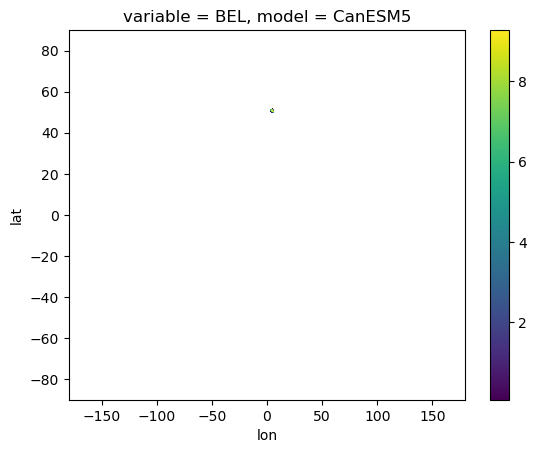

In [105]:
(countrymasks_nan * da_nAHD_TX99_models).sel(variable='BEL').isel(model=0).plot()

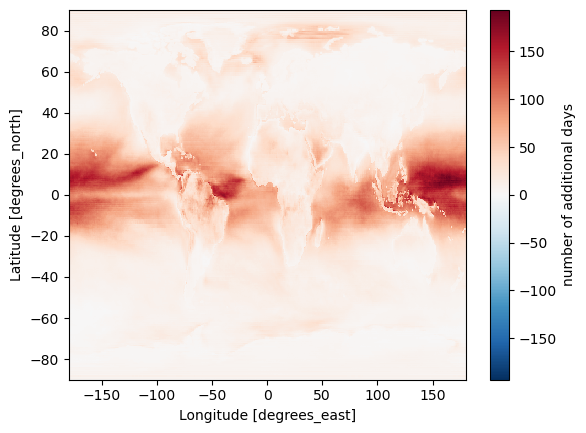

In [106]:
da_nAHD_TX99_models.median(dim='model').plot()

In [107]:

df_nAHD_countries = (countrymasks_nan * da_nAHD_TX99_models).weighted(cellarea).mean(dim=['lat','lon']).to_pandas()
df = df_nAHD_countries
df_nAHD_countries_summary = reporting_summary(df, ['median', 'min', 'max']).round(1)
df_nAHD_countries_summary.loc['BEL']

median    2.6
min      -0.7
max       5.2
Name: BEL, dtype: float64

In [108]:
df_nAHD_countries_summary.sort_values('median')

,median,min,max
variable,,,
AND,0.7,0.4,1.6
LUX,1.0,-0.2,1.8
BGD,1.3,-0.7,6.7
URY,1.4,-1.5,6.8
LTU,1.9,-0.4,7.1
...,...,...,...
MHL,83.4,33.0,120.8
FSM,83.8,23.1,121.3
SLB,84.0,44.4,125.9


In [109]:
df_nAHD_countries = (countrymasks_nan * da_nAHD_TX95_models).weighted(cellarea).mean(dim=['lat','lon']).to_pandas()
df = df_nAHD_countries
df_nAHD_countries_summary = reporting_summary(df, ['median', 'min', 'max']).round(1)
df_nAHD_countries_summary.loc['BEL']

median     6.4
min        0.1
max       10.9
Name: BEL, dtype: float64

In [110]:
df_nAHD_countries = (countrymasks_nan * da_nAHD_TX90_models).weighted(cellarea).mean(dim=['lat','lon']).to_pandas()
df = df_nAHD_countries
df_nAHD_countries_summary = reporting_summary(df, ['median', 'min', 'max']).round(1)
df_nAHD_countries_summary.loc['BEL']

median     9.1
min        2.1
max       16.0
Name: BEL, dtype: float64

In [111]:


df_nAHD_countries = (countrymasks_nan * da_nAHD_obs_TX99).weighted(cellarea).mean(dim=['lat','lon']).to_pandas()
df = df_nAHD_countries
df_nAHD_countries_summary = reporting_summary(df, ['median', 'min', 'max']).round(1)
df_nAHD_countries_summary.loc['BEL']


median    4.8
min       4.3
max       6.8
Name: BEL, dtype: float64

In [112]:

df_nAHD_countries = (countrymasks_nan * da_nAHD_obs_TX95).weighted(cellarea).mean(dim=['lat','lon']).to_pandas()
df = df_nAHD_countries
df_nAHD_countries_summary = reporting_summary(df, ['median', 'min', 'max']).round(1)
df_nAHD_countries_summary.loc['BEL']


median    12.5
min       11.5
max       15.9
Name: BEL, dtype: float64

In [113]:

df_nAHD_countries = (countrymasks_nan * da_nAHD_obs_TX90).weighted(cellarea).mean(dim=['lat','lon']).to_pandas()
df = df_nAHD_countries
df_nAHD_countries_summary = reporting_summary(df, ['median', 'min', 'max']).round(1)
df_nAHD_countries_summary.loc['BEL']


median    17.3
min       16.1
max       20.5
Name: BEL, dtype: float64

## Check Australia

In [114]:
pop_children = (
    gs_population_global
    .sel(ages=slice(0, 9))
    .sum("ages")
)

exposed = pop_children.where(da_nAHD_models > 30)

In [116]:
[name for name in ar6.names if "AUSTRALIA" in name.upper()]

['N.Australia', 'C.Australia', 'E.Australia', 'S.Australia']

In [117]:
north_aus_id = ar6.map_keys('N.Australia')
north_aus_id

39

In [119]:
mask

<xarray.DataArray 'mask' (lat: 360, lon: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [44., 44., 44., ..., 44., 44., 44.],
       [44., 44., 44., ..., 44., 44., 44.],
       [44., 44., 44., ..., 44., 44., 44.]])
Coordinates:
  * lat      (lat) float64 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    standard_name:  region
    flag_values:    [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18...
    flag_meanings:  GIC NWN NEN WNA CNA ENA NCA SCA CAR NWS NSA NES SAM SWS S...

In [120]:
north_aus = (
    exposed
    .where(mask == north_aus_id)
    .sum(dim=["lat","lon"])
    .median("model")
)

print("Northern Australia:", float(north_aus) / 1e3)

Northern Australia: 225.93300852295053


In [130]:
#countrymasks_nan['variable'].values

In [129]:
aus = (
    exposed * countrymasks_nan.sel(variable='AUS')
).sum(
    dim=["lat", "lon"],
    skipna=True
).median("model")

print("Australia:", float(aus) / 1e3)

Australia: 87.83174704648086


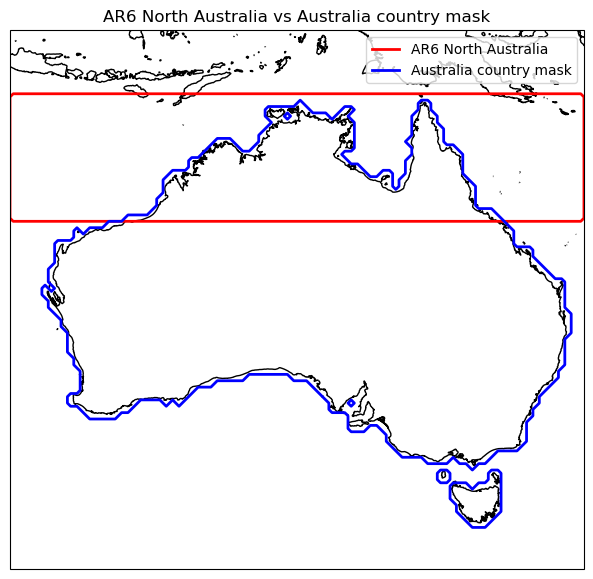

In [133]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

# AR6 North Australia mask
north_aus_mask = (mask == north_aus_id)

# Australia country mask
aus_mask = countrymasks_nan.sel(variable="AUS").notnull()

fig, ax = plt.subplots(
    figsize=(9, 7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

north_aus_mask.astype(int).plot.contour(
    ax=ax,
    levels=[0.5],
    colors=["red"],
    linewidths=2,
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)

aus_mask.astype(int).plot.contour(
    ax=ax,
    levels=[0.5],
    colors=["blue"],
    linewidths=2,
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)

# Country borders / coastline
#ax.add_feature(cfeature.BORDERS, linewidth=1, edgecolor="black")
ax.coastlines(resolution="10m", linewidth=1)

ax.set_extent([110, 155, -45, -5])

ax.legend(handles=[
    Line2D([0], [0], color="red", lw=2, label="AR6 North Australia"),
    Line2D([0], [0], color="blue", lw=2, label="Australia country mask"),
])

plt.title("AR6 North Australia vs Australia country mask")
plt.show()

In [134]:
north_aus = (mask == north_aus_id)
aus = countrymasks_nan.sel(variable="AUS").notnull()

# NAU but NOT Australia
nau_outside_aus = north_aus & ~aus

exposed_outside_aus = (
    exposed
    .where(nau_outside_aus)
    .sum(dim=["lat", "lon"])
    .median("model")
)

print(
    "Exposed children in NAU but outside Australia:",
    float(exposed_outside_aus) / 1e3
)

Exposed children in NAU but outside Australia: 152.2224494525816


In [135]:
exposed_nau_australia = (
    exposed
    .where(north_aus & aus)
    .sum(dim=["lat", "lon"])
    .median("model")
)

print(
    "Exposed children in Australian part of NAU:",
    float(exposed_nau_australia) / 1e3
)

Exposed children in Australian part of NAU: 73.7105590703689


In [136]:
# total children aged 0–9
pop_children = (
    gs_population_global
    .sel(ages=slice(0, 9))
    .sum(dim="ages")
)

# masks
north_aus_mask = (mask == north_aus_id)
aus_mask = countrymasks_nan.sel(variable="AUS").notnull()


# total children in AR6 North Australia
children_nau_total = (
    pop_children
    .where(north_aus_mask)
    .sum(dim=["lat", "lon"], skipna=True)
)

# total children in Australia
children_aus_total = (
    pop_children
    .where(aus_mask)
    .sum(dim=["lat", "lon"], skipna=True)
)


print("Children in NAU:", float(children_nau_total) / 1e3, "thousand")
print("Children in Australia:", float(children_aus_total) / 1e3, "thousand")

Children in NAU: 294.54095571812263 thousand
Children in Australia: 3269.7454639501584 thousand


In [137]:
children_nau_inside_aus = (
    pop_children
    .where(north_aus_mask & aus_mask)
    .sum(dim=["lat", "lon"], skipna=True)
)

children_nau_outside_aus = (
    pop_children
    .where(north_aus_mask & ~aus_mask)
    .sum(dim=["lat", "lon"], skipna=True)
)

print("NAU total:       ", float(children_nau_total) / 1e3, "thousand")
print("NAU in Australia:", float(children_nau_inside_aus) / 1e3, "thousand")
print("NAU outside Aus: ", float(children_nau_outside_aus) / 1e3, "thousand")
print("Australia total: ", float(children_aus_total) / 1e3, "thousand")

NAU total:        294.54095571812263 thousand
NAU in Australia: 93.01632162597241 thousand
NAU outside Aus:  201.52463409215022 thousand
Australia total:  3269.7454639501584 thousand


In [ ]:
results = {}

for country in countrymasks_nan["variable"].values:
    
    country_mask = countrymasks_nan.sel(variable=country).notnull()
    
    # intersection of country with AR6 North Australia
    country_nau_mask = north_aus_mask & country_mask
    
    n_children_exposed = (
        pop_children
        .where(da_nAHD_models > 30)
        .where(country_nau_mask)
        .sum(dim=["lat", "lon"], skipna=True)
        .median(dim="model")
        .item()
    )
    
    if n_children_exposed > 0:
        results[country] = round(n_children_exposed / 1e3)
        
results = dict(
    sorted(results.items(), key=lambda x: x[1], reverse=True)
)

results

{'IDN': 116, 'AUS': 74, 'PNG': 36}

In [155]:
rows = []

for region_id, region_name in enumerate(ar6.names):

    region_mask = (mask == region_id)

    countries = []

    for iso3 in countrymasks_nan["variable"].values:

        country_mask = countrymasks_nan.sel(variable=iso3).notnull()

        # Does this country overlap the AR6 region?
        if (region_mask & country_mask).any().item():
            countries.append(iso3)

    rows.append({
        "IPCC AR6 region": region_name,
        "countries_ISO3": countries
    })

df_ar6_countries = pd.DataFrame(rows)

df_ar6_countries["Countries"] = df_ar6_countries["countries_ISO3"].apply(
    lambda countries: [
        df_countrynames.loc[iso3, "Country"]
        for iso3 in countries
        if iso3 in df_countrynames.index
    ]
)

df_ar6_countries = df_ar6_countries[
    ["IPCC AR6 region", "Countries"]
]


df_ar6_countries["Countries"] = (
    df_ar6_countries["Countries"]
    .apply(lambda x: ", ".join(x))
)

df_ar6_countries

,IPCC AR6 region,Countries
0,Greenland/Iceland,"Canada, Iceland"
1,N.W.North-America,"Canada, United States of America"
2,N.E.North-America,Canada
3,W.North-America,"Canada, United States of America"
4,C.North-America,"Canada, United States of America"
5,E.North-America,"Bahamas, Canada, United States of America"
6,N.Central-America,"Mexico, United States of America"
7,S.Central-America,"Belize, Costa Rica, Guatemala, Honduras, Mexic..."
8,Caribbean,"Antigua and Barbuda, Bahamas, Barbados, Colomb..."
9,N.W.South-America,"Brazil, Colombia, Ecuador, Panama, Peru, Venez..."


In [ ]:
#df_ar6_countries.to_excel(figdir+'/supplementary_data_countries_inAR6_region.xlsx')

In [154]:
figdir

'/data/brussel/vo/000/bvo00012/vsc10419/attr-hw/figures/fig_apr26'